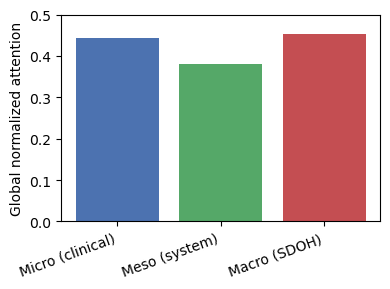

In [2]:
import matplotlib.pyplot as plt

tiers = ['Micro (clinical)', 'Meso (system)', 'Macro (SDOH)']
values = [0.444, 0.381, 0.452]

plt.figure(figsize=(4, 3))
bars = plt.bar(tiers, values, color=['#4c72b0', '#55a868', '#c44e52'])

plt.ylabel('Global normalized attention')
plt.ylim(0, 0.5)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
#plt.savefig('fig_global_attention_tiers.png', dpi=300)
#plt.savefig('fig_global_attention_tiers.pdf')
#plt.close()

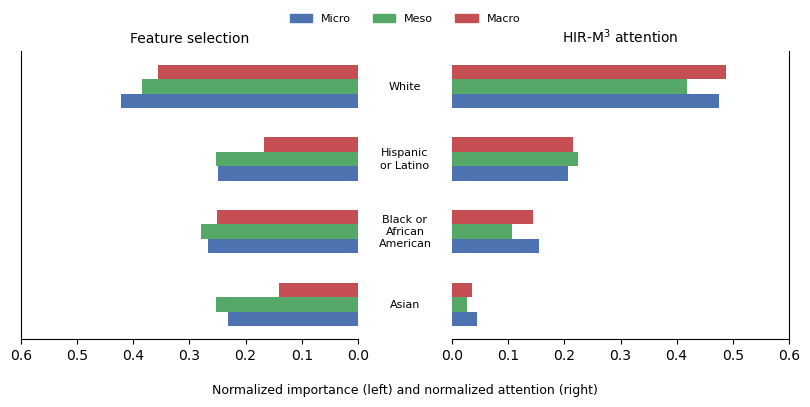

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

races = ['Asian',
         'Black or\nAfrican\nAmerican',
         'Hispanic\nor Latino',
         'White']
y = np.arange(len(races))

# Table 5: Feature selection
fs_micro = np.array([0.231, 0.267, 0.250, 0.422])
fs_meso  = np.array([0.252, 0.279, 0.253, 0.384])
fs_macro = np.array([0.140, 0.251, 0.167, 0.356])

# Table 7: HIR-M3 attention
att_micro = np.array([0.044, 0.155, 0.206, 0.475])
att_meso  = np.array([0.026, 0.106, 0.224, 0.419])
att_macro = np.array([0.036, 0.144, 0.215, 0.488])

bar_height = 0.2
colors = {
    'Micro': '#4c72b0',
    'Meso':  '#55a868',
    'Macro': '#c44e52'
}

fig = plt.figure(figsize=(8.2, 4.2))          # taller to give rows more room
gs = GridSpec(1, 3, width_ratios=[1, 0.28, 1], wspace=0.0)  # wider middle
ax_left  = fig.add_subplot(gs[0, 0])
ax_mid   = fig.add_subplot(gs[0, 1], sharey=ax_left)
ax_right = fig.add_subplot(gs[0, 2], sharey=ax_left)

# ----- LEFT: Feature selection -----
ax_left.barh(y - bar_height, fs_micro, bar_height, color=colors['Micro'], label='Micro')
ax_left.barh(y,               fs_meso,  bar_height, color=colors['Meso'],  label='Meso')
ax_left.barh(y + bar_height, fs_macro, bar_height, color=colors['Macro'], label='Macro')
ax_left.set_title('Feature selection', fontsize=10)
ax_left.set_xlim(0.6, 0)
ax_left.set_yticks(y)
ax_left.tick_params(axis='y', left=False, labelleft=False)
ax_left.invert_yaxis()

# ----- MIDDLE: shared race labels -----
ax_mid.set_xlim(0, 1)
ax_mid.set_xticks([])
ax_mid.set_yticks(y)
ax_mid.set_yticklabels([])
ax_mid.tick_params(axis='y', length=0, pad=0)
for spine in ax_mid.spines.values():
    spine.set_visible(False)
ax_mid.set_facecolor('none')

for i, race in zip(y, races):
    ax_mid.text(0.5, i, race,
                ha='center', va='center',
                fontsize=8,
                linespacing=1.3,
                multialignment='center',
                transform=ax_mid.get_yaxis_transform())

# ----- RIGHT: HIR-M3 attention -----
ax_right.barh(y - bar_height, att_micro, bar_height, color=colors['Micro'])
ax_right.barh(y,               att_meso,  bar_height, color=colors['Meso'])
ax_right.barh(y + bar_height, att_macro, bar_height, color=colors['Macro'])
ax_right.set_title('HIR-M$^3$ attention', fontsize=10)
ax_right.set_xlim(0, 0.6)
ax_right.set_yticks(y)
ax_right.tick_params(axis='y', left=False, labelleft=False)
ax_right.invert_yaxis()

# Clean panel borders
ax_left.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_left.spines['top'].set_visible(False)
ax_right.spines['top'].set_visible(False)
ax_mid.spines['top'].set_visible(False)
ax_mid.spines['bottom'].set_visible(False)

# Shared legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Micro']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Meso']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Macro'])
]
fig.legend(handles, ['Micro', 'Meso', 'Macro'],
           loc='upper center', ncol=3, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, 0.94))

# Shared x-label
fig.text(0.5, 0.02,
         'Normalized importance (left) and normalized attention (right)',
         ha='center', va='center', fontsize=9)
plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('fig_tier_race.png', dpi=300, bbox_inches='tight')
plt.savefig('fig_tier_race.pdf', bbox_inches='tight')
plt.show()

#plt.close()